# **Chapter 2 - Digital Fourier Transforms**
## Fourier Transforms (analytic and continuous)
Chapter 2 of [J. Schmidt](https://www.spiedigitallibrary.org/ebooks/PM/Numerical-Simulation-of-Optical-Wave-Propagation-with-Examples-in-MATLAB/eISBN-9780819483270/10.1117/3.866274)'s book contains the basics of Fourier Transforms. In many cases, analytic solutions are intractable, hence the need for discretisation.

\begin{equation}
  G(f_x)=\mathcal{F}\{g(x)\}=\int_{-\infty}^\infty g(x)e^{-i2\pi f_xx}dx
  \label{eq:analyticFT}
\end{equation}

- $x$ is the spacial variable and $f_x$ is the spacial frequency variable. <br>
The inverse is given as:

\begin{equation}
  g(x)=\mathcal{F}\{G(f_x)\}=\int_{-\infty}^{\infty}G(f_x)e^{i2\pi f_xx}df_x
  \label{eq:analyticIFT}
\end{equation}

To disretise equation \eqref{eq:analyticFT} we can write it as a Riemann sum:

\begin{equation}
    \sum_{n=-\infty}^{\infty}g(x_n)e^{-i2\pi f_{xm}x_n}(x_{n+1}-x_n), \qquad m=-\infty,...\infty,
    \label{eq:riemannsumFT}
\end{equation}

To put further constraint, we can introduce a finite number of samples for tractability. The book only takes an even number of $N$ and a fixed sampling interval. <br>
- $\delta$ = Sampling interval
- $x_n=n\delta$
- $\delta_f = \frac{1}{(N\delta)}$ = Frequency domain interval
- $f_{xm}=m\delta_f=\frac{m}{(N\delta)}$

Therefore, equation \eqref{eq:riemannsumFT} becomes:
\begin{equation}
    G(\frac{m}{N\delta})=\mathcal{F}\{g(n\delta)\}=\delta \sum_{n=-N/2}^{N/2-1}g(n\delta)e^{-i2\pi mn/N}, \qquad m=-N/2,1-N/2,...N/2-1.
    \label{eq:finiteriemannsumFT}
\end{equation}

Throughout the book, the `fftshift` is a common theme. In the 1D spacial case, notice that the origin is located at the centre. We perform a `fftshift` such that the origin is located at the **first** sample. Presumably, this is because fft assumes the origin to be the first sample. Here is an example of the function in action:

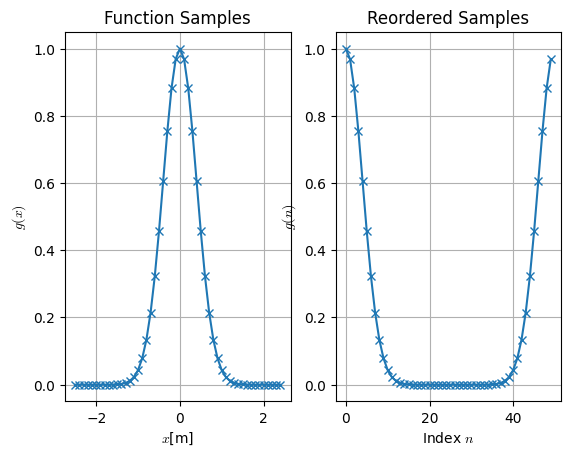

In [18]:
import numpy as np
import matplotlib.pyplot as plt

DISPLAY_FIGS = True

# Define gaussian function
def gaussian(x,a):
    y = np.exp(-np.pi*(a*x)**2)
    return y

# Create gaussian function
a = 1
x = np.arange(-3,3,0.2)
y = gaussian(x,a)
y_shifted = np.fft.fftshift(y)

# Display figures
if DISPLAY_FIGS:
    fig,ax = plt.subplots(1,2)
    ax[0].plot(x,y,marker='x')
    ax[0].set_xlabel(r"$x$[m]",math_fontfamily='cm')
    ax[0].set_ylabel(r"$g(x)$",math_fontfamily='cm')
    ax[0].set_title("Function Samples")
    ax[0].grid(visible=True,which='both')

    ax[1].plot(y_shifted,marker='x')
    ax[1].set_xlabel(r"Index $n$",math_fontfamily='cm')
    ax[1].set_ylabel(r"$g(n)$",math_fontfamily='cm')
    ax[1].set_title("Reordered Samples")
    ax[1].grid(visible=True,which='both')
    plt.show()

For chapter 2, Listing 2.3 contains an example of the `ft` function with a gaussian input. Where the gaussian is defined by:
\begin{equation}
    g(x)=e^{-\pi ax^2}
\end{equation}

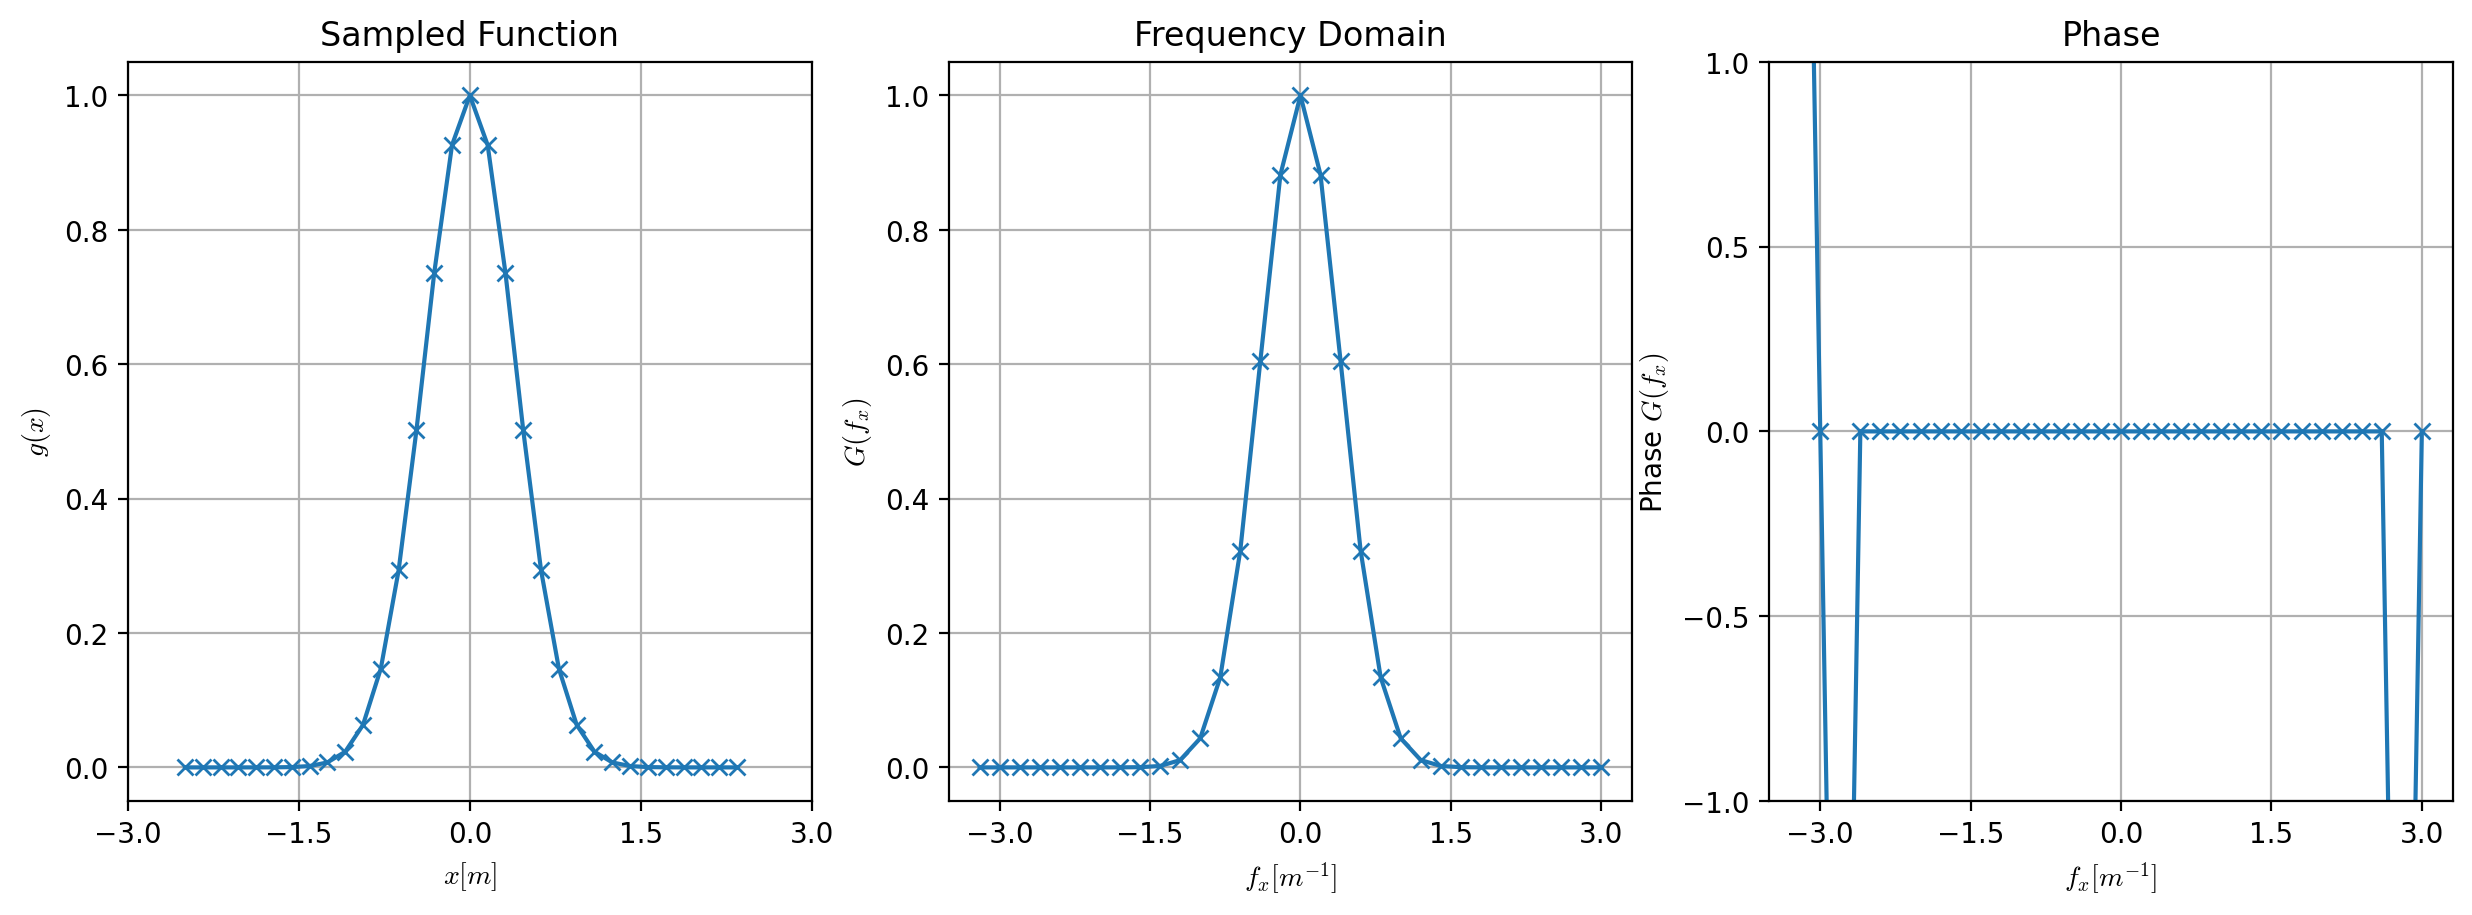

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from optical_functions.ft_functions import ft

# Optic parameters
L = 5   # Spacial extent of grid [m]
N = 32
delta = L/N
x = np.arange(-N/2,N/2,1) * delta
f = np.arange(-N/2,N/2,1) / (N*delta)
a = 1
g_samp = np.exp(-np.pi*a*(x**2))
g_dft = ft(g_samp,delta)

fig,ax = plt.subplots(1,3)
fig.set_figwidth(15)
ax[0].plot(x,g_samp,marker='x')
ax[0].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[0].set_xticks(np.arange(-3,4.5,1.5))
ax[0].set_ylabel(r"$g(x)$",math_fontfamily='cm')
ax[0].set_title("Sampled Function")
ax[0].grid(visible=True,which='both')

ax[1].plot(f,np.abs(g_dft),marker='x')
ax[1].set_xlabel(r"$f_x[m^{-1}]$",math_fontfamily='cm')
ax[1].set_xticks(np.arange(-3,4.5,1.5))
ax[1].set_ylabel(r"$G(f_x)$",math_fontfamily='cm')
ax[1].set_title("Frequency Domain")
ax[1].grid(visible=True,which='both')

ax[2].plot(f,np.angle(g_dft),marker='x')
ax[2].set_xlabel(r"$f_x[m^{-1}]$",math_fontfamily='cm')
ax[2].set_xticks(np.arange(-3,4.5,1.5))
ax[2].set_ylabel(r"Phase $G(f_x)$",math_fontfamily='cm')
ax[2].set_ylim(-1,1)
ax[2].set_yticks(np.arange(-1,1.5,0.5))
ax[2].set_title("Phase")
ax[2].grid(visible=True,which='both')
plt.show()